---
title: "Poisson Equation"
format: 
    html: 
        toc: true
execute: 
  enabled: true
bibliography: "../../references.bib"
jupyter: python3
---

In this example, we illustrate how we can build a DIRT to perform (approximate) amortised inference. The key idea is to build a DIRT approximation to the joint density of the observations and parameters; then, as a consequence of the triangular structure of the DIRT mapping, we can sample from the DIRT approximation to the posterior of the parameters, for any realisation of the observations, in real time. For further details on the ideas behind amortised inference, see @Cui2023.

# Problem Setup

We consider the Poisson equation defined in domain $\Omega := (0, 1) \times (0, 1)$, with boundary denoted by $\partial \Omega$; that is,

$$
  \nabla \cdot (\kappa(\boldsymbol{x}) \nabla u(\boldsymbol{x})) = 0, \quad \boldsymbol{x} \in \Omega.
$$

This equation can be used to model the flow of fluid in a porous medium, in which case $u(\boldsymbol{x})$ denotes the fluid pressure and $\kappa(\boldsymbol{x})$ denotes the diffusion coefficient. Following @Cui2025, we impose the boundary conditions

$$
\begin{align*}
    u(\boldsymbol{x}) &= 1 + \frac{x_{1}}{2}, \qquad &&\boldsymbol{x} \in \partial\Omega_{\mathrm{L}}, \\
    u(\boldsymbol{x}) &= -\sin(2\pi x_{2}) - 1, \qquad &&\boldsymbol{x} \in \partial\Omega_{\mathrm{R}}, \\
    (\kappa(\boldsymbol{x}) u(\boldsymbol{x})) \cdot \boldsymbol{n} &= 0, \qquad &&\boldsymbol{x} \in \partial\Omega_{\mathrm{T}} \cup \partial\Omega_{\mathrm{B}}.
\end{align*}
$$

In the above, $\partial\Omega_{\mathrm{L}}$, $\partial\Omega_{\mathrm{R}}$, $\partial\Omega_{\mathrm{T}}$, and $\partial\Omega_{\mathrm{B}}$ denote the left, right, top and bottom boundaries respectively, and $\boldsymbol{n}$ denotes the outward-facing normal vector on the boundary.

## Prior Density

We endow the logarithm of the unknown diffusion coefficient with a process convolution prior; that is,

$$
    \log(\kappa(\boldsymbol{x})) = \log(\bar{\kappa}(\boldsymbol{x})) + \sum_{i=1}^{d} \xi^{(i)} \exp\left(-\frac{1}{2r^{2}}\left\lVert\boldsymbol{x} - \boldsymbol{x}^{(i)}\right\rVert^{2}\right),
$$

where $d=9$, $\log(\bar{\kappa}(\boldsymbol{x})) = 0$, $r=1/20$, the coefficients $\{\xi^{(i)}\}_{i=1}^{d}$ are independent and follow the unit Gaussian distribution, and the centres of the kernel functions, $\{\boldsymbol{x}^{(i)}\}_{i=1}^{d}$, are equispaced over the domain (see @fig-prior-samples).

## Data

We assume that we will receive four measurements of the fluid pressure, $u(\boldsymbol{x})$, at locations $[0.3, 0.3]^{\top}$, $[0.3, 0.7]^{\top}$, $[0.7, 0.3]^{\top}$, and $[0.7, 0.7]^{\top}$. All measurements will be corrupted by i.i.d. Gaussian noise with zero mean and a standard deviation of $\sigma = 0.2$.

# Implementation in $\texttt{deep\_tensor}$

In [1]:
from matplotlib import pyplot as plt
import torch
from torch import Tensor

import deep_tensor as dt

from examples.poisson.setup import setup_poisson_problem
from examples.plotting import (
    add_arrows, 
    pairplot, 
    plot_dl_function, 
    set_plot_style
)

In [ ]:
torch.manual_seed(0)
set_plot_style()

We begin by defining the prior density and forward model. Note that in this example, the forward model is written in [FEniCS](https://fenicsproject.org/download/archive/) and discretised on a $32 \times 32$ mesh.

In [ ]:
prior, model = setup_poisson_problem()

@fig-prior-samples shows a set of samples from the prior.

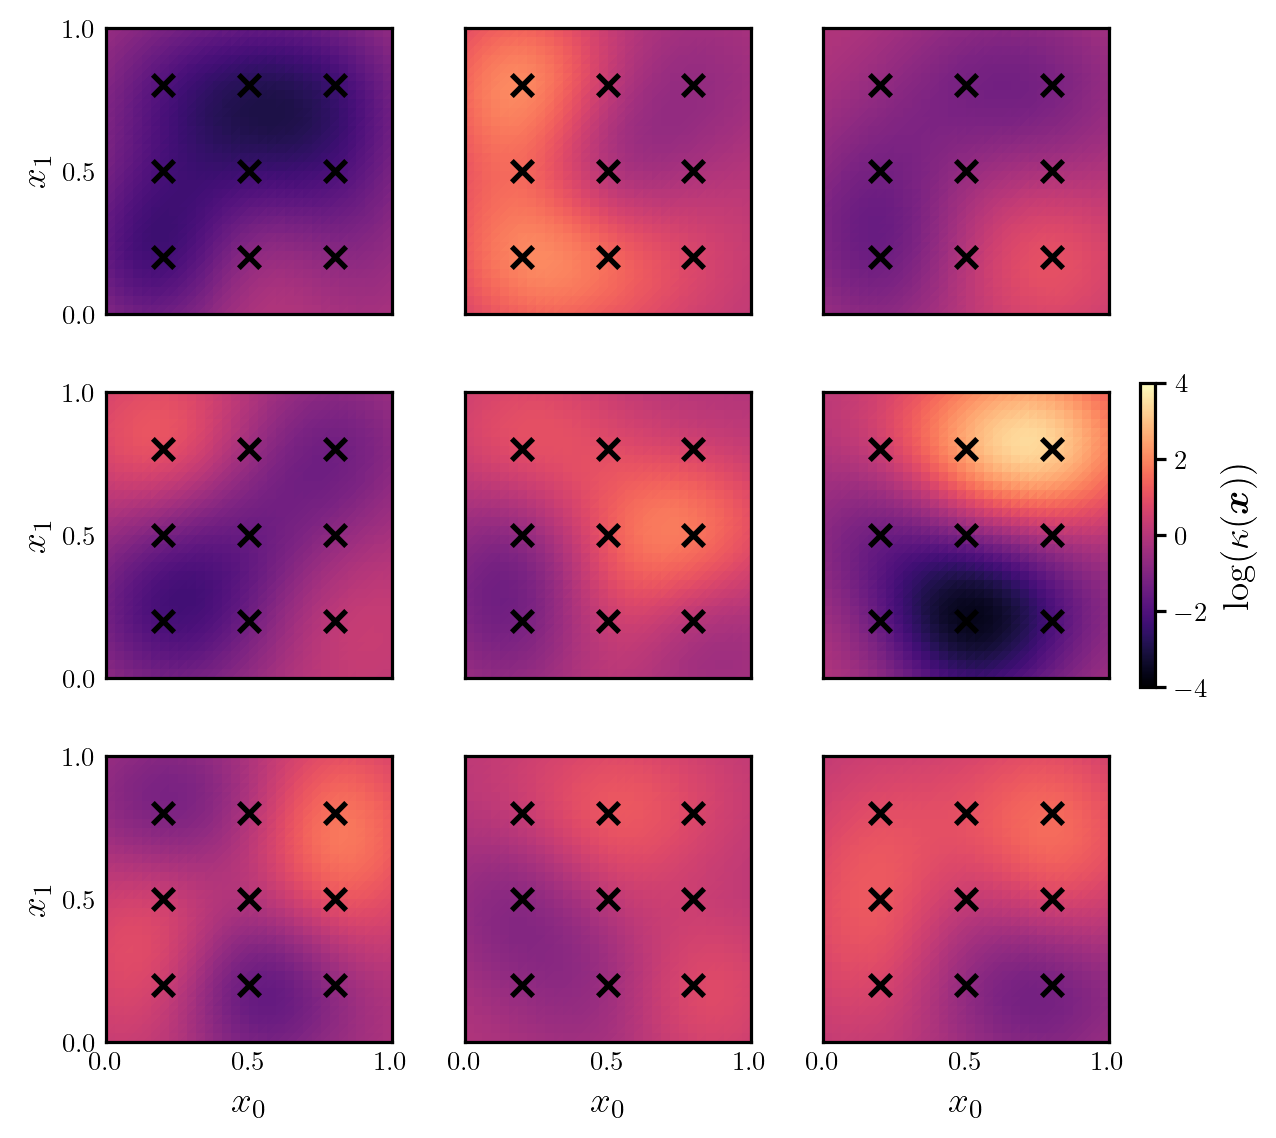

In [ ]:
#| code-fold: true
#| fig-align: center
#| fig-cap: Samples of $\log(\kappa(\boldsymbol{x}))$ drawn from the prior. The crosses in each plot show the centres of the kernel functions used when defining the prior.
#| label: fig-prior-samples

fig, axes = plt.subplots(3, 3, sharex=True, sharey=True, figsize=(6.65, 6.0))

prior_samples = [
    prior.transform(sample)
    for sample in prior.sample(n=9)
]

for i, ax in enumerate(axes.flat):
    
    plot_dl_function(
        fig, ax, 
        model.vec2func(prior_samples[i]), 
        plot_cbar=(i==5), 
        cbar_label=r"$\log(\kappa(\bm{x}))$", 
        cmap="magma",
        vmin=-4.0, 
        vmax=4.0
    )

    ax.scatter(*prior.ss.T, c="k", marker="x")

    ax.set_xticks([0.0, 0.5, 1.0])
    ax.set_yticks([0.0, 0.5, 1.0])
    ax.tick_params(axis="both", which="both", length=0)
    ax.set_xlabel("$x_{0}$" if i > 5 else None)
    ax.set_ylabel("$x_{1}$" if (i % 3) == 0 else None)

## DIRT Construction

We now construct a DIRT approximation to the joint density of the observations and parameters.

We first define a function that returns the potential function of (a quantity proportional to) the joint density.

In [5]:
sd_noise = 0.2

def neglogjoint(yxs: Tensor) -> Tensor:
    """Evaluates the potential function of (a quantity proportional to) 
    the joint density of the observations and parameters.
    """

    ys_obs, xs = yxs[:, :model.num_obs], yxs[:, model.num_obs:]

    ys = torch.vstack([
        model.observe(model.solve(prior.transform(x_i)))
        for x_i in xs
    ])
    
    neglogliks = (0.5 / sd_noise**2) * (ys_obs - ys).square().sum(dim=1)
    neglogpris = 0.5 * xs.square().sum(dim=1)

    return neglogliks + neglogpris

target_func = dt.TargetFunc(neglogjoint)

Next, we specify a preconditioning mapping. Note that in this example, we can easily sample from the joint density of the parameters and observations (by sampling from the prior and applying the forward model to these samples, then adding some synthetic realisations of noise). To create a preconditioner, we will generate a set of samples, fit a Gaussian density to these, and use a coupling between this density and the unit Gaussian density as the initial guess for the DIRT approximation.

We begin by generating a set of samples from the joint density. @fig-joint-samples shows a pair plot of the samples of the observations, $\{y_{i}\}_{i=1}^{4}$, and the first two parameters, $\{\xi_{i}\}_{i=1}^{2}$.

In [6]:
num_solves = 5000

x_samples = prior.sample(num_solves)
logk_samples = torch.vstack([prior.transform(x_i) for x_i in x_samples])
noise_samples = sd_noise * torch.randn((num_solves, model.num_obs))

y_obs_samples = torch.vstack([
    model.observe(model.solve(logk_samples[i])) + noise_samples[i]
    for i in range(num_solves)
])

joint_samples = torch.hstack((y_obs_samples, x_samples))

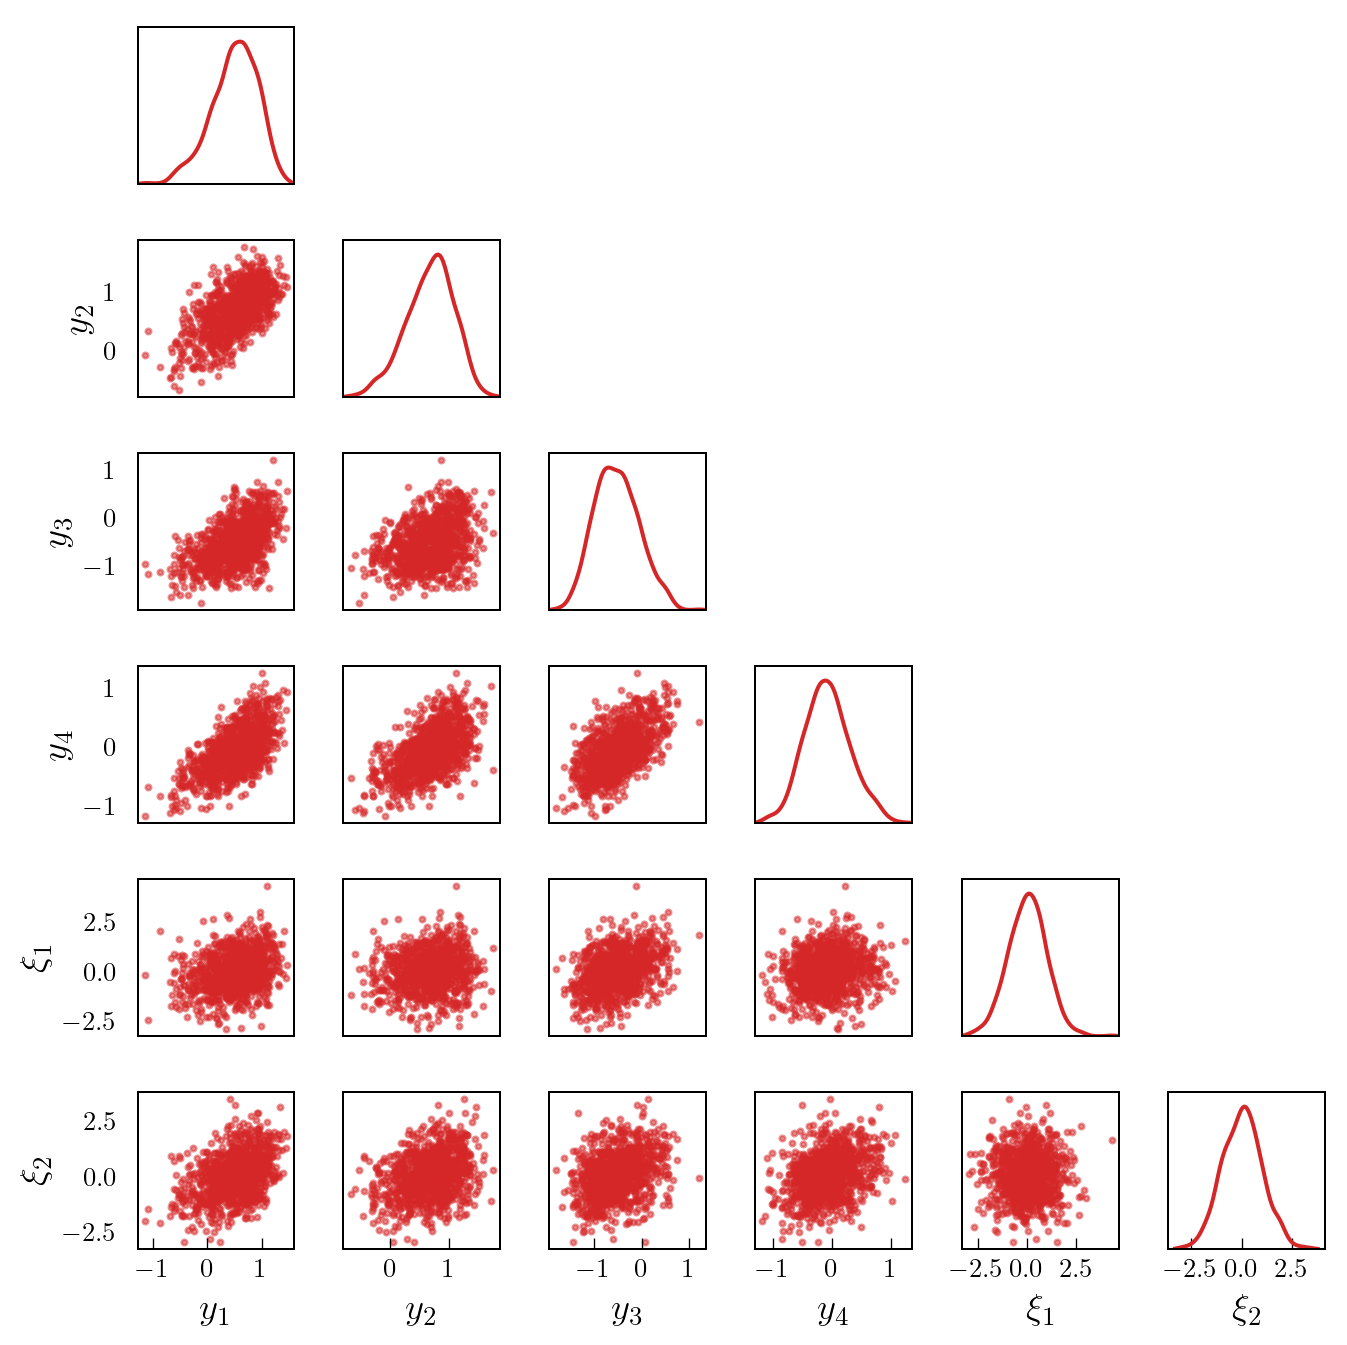

In [7]:
#| code-fold: true
#| fig-align: center
#| fig-cap: Samples of the observations, $\{y_{i}\}_{i=1}^{4}$, and the first two parameters, $\{\xi_{i}\}_{i=1}^{2}$, drawn from the joint density.
#| label: fig-joint-samples

labels = [r"$y_{"+f"{i+1}"+r"}$" for i in range(4)] + [r"$\xi_{"+f"{i+1}"+r"}$" for i in range(2)]
pairplot(joint_samples[::5, :6], labels=labels)

We then fit a Gaussian density to these samples and define the preconditioning mapping. 

In [ ]:
mean_joint = joint_samples.mean(dim=0)
cov_joint = joint_samples.T.cov()
dim_joint = mean_joint.numel()

domain = dt.BoundedDomain([-5.0, 5.0])
reference = dt.GaussianReference(domain)
preconditioner = dt.GaussianMapping(mean_joint, cov_joint, reference)

Next, we construct a functional tensor train (FTT) object.

In [9]:
basis = dt.Fourier(order=15)
bases = dt.ApproxBases(basis, dim_joint)
tt_options = dt.TTOptions(
    tt_method="fixed_rank", 
    init_rank=7, 
    max_als=1, 
    tol_l2_error=1.0e-01, 
    verbose=0
)
tt = dt.TT(tt_options)
ftt = dt.FTT(bases, tt)

We then define the sequence of bridging densities that will be approximated at each layer of the DIRT construction.

In [10]:
betas = 10.0 ** torch.linspace(-3.0, 0.0, 10)
bridge = dt.Tempering(betas)

Finally, we construct the DIRT approximation to the joint density.

In [11]:
dirt = dt.DIRT(target_func, preconditioner, ftt, bridge)

[DIRT] Iter:  1 | Cum. Fevals: 0.00e+00 | Cum. Time: 2.20e+00 s | DHell: 0.0000 | Beta: 0.0010 | ESS: 1.0000


[DIRT] Iter:  2 | Cum. Fevals: 1.87e+04 | Cum. Time: 4.79e+01 s | DHell: 0.0006 | Beta: 0.0022 | ESS: 1.0000


[DIRT] Iter:  3 | Cum. Fevals: 3.74e+04 | Cum. Time: 9.47e+01 s | DHell: 0.0008 | Beta: 0.0046 | ESS: 1.0000


[DIRT] Iter:  4 | Cum. Fevals: 5.61e+04 | Cum. Time: 1.42e+02 s | DHell: 0.0013 | Beta: 0.0100 | ESS: 0.9999


[DIRT] Iter:  5 | Cum. Fevals: 7.48e+04 | Cum. Time: 1.91e+02 s | DHell: 0.0027 | Beta: 0.0215 | ESS: 0.9996


...

[DIRT] Iter:  7 | Cum. Fevals: 1.12e+05 | Cum. Time: 2.91e+02 s | DHell: 0.0097 | Beta: 0.1000 | ESS: 0.9931


[DIRT] Iter:  8 | Cum. Fevals: 1.31e+05 | Cum. Time: 3.43e+02 s | DHell: 0.0195 | Beta: 0.2154 | ESS: 0.9763


[DIRT] Iter:  9 | Cum. Fevals: 1.50e+05 | Cum. Time: 3.97e+02 s | DHell: 0.0400 | Beta: 0.4642 | ESS: 0.9181


[DIRT] Iter: 10 | Cum. Fevals: 1.68e+05 | Cum. Time: 4.52e+02 s | DHell: 0.0749 | Beta: 1.0000 | ESS: 0.7333


[DIRT] DIRT construction complete.
[DIRT]  • Layers: 10.
[DIRT]  • Total function evaluations: 186,960.
[DIRT]  • Total time: 8.46 mins.
[DIRT]  • DHell: 0.1643.


## Amortised Inference

We can now use the constructed DIRT object to sample from an approximation to the (parameter) posterior density associated with an arbitrary set of observations.

This is done by calling the `eval_cirt()` method of the DIRT approximation with the set of observations, and a set of samples from the reference density with the same dimension as the parameters. The samples from the reference density will be transformed into samples distributed according to an approximation of the posterior associated with the particular realisation of the data.

In [12]:
# Generate some observations
x = prior.sample(n=1)
logk = prior.transform(x.flatten())
y_obs = model.observe(model.solve(logk)) + sd_noise * torch.randn(model.num_obs)

# Generate a set of samples from the reference
num_conditional_samples = 5000
rs = dirt.reference.random(n=num_conditional_samples, d=prior.dim)

# Transform the samples such that they are distributed according to the 
# DIRT approximation to the posterior
xs_cond, neglogfxs_cond_dirt = dirt.eval_cirt(y_obs, rs)

We can use the DIRT approximation to the posterior to define a proposal density for an MCMC sampler, or for importance sampling. In this example, we will illustrate the use of the DIRT approximation to define proposals for an independence MCMC sampler.

In [13]:
def neglogpost(xs: Tensor, ys_obs: Tensor) -> Tensor:
    """Evaluates the potential function associated with (a function 
    proportional to) the posterior for a given dataset.
    """

    ys = torch.vstack([
        model.observe(model.solve(prior.transform(x_i)))
        for x_i in xs
    ])
    
    neglogliks = (0.5 / sd_noise**2) * (ys_obs - ys).square().sum(dim=1)
    neglogpris = 0.5 * xs.square().sum(dim=1)

    return neglogliks + neglogpris

neglogfxs_cond_true = neglogpost(xs_cond, y_obs)

res = dt.run_independence_sampler(
    xs_cond, 
    neglogfxs_cond_dirt, 
    neglogfxs_cond_true
)

print(f"Acceptance rate: {res.acceptance_rate:.2f}.")
print(f"Mean IACT: {res.iacts.mean():.2f}.")
print(f"Max IACT: {res.iacts.max():.2f}.")

Acceptance rate: 0.84.
Mean IACT: 1.85.
Max IACT: 2.30.


The plots in @fig-diagnostics show the acceptance rate, mean IACT and maximum IACT (across all parameters) for independence MCMC samplers (which use the conditional DIRT to define the proposal density) for 30 random realisations of data. The samplers appear to be quite efficient in most cases.

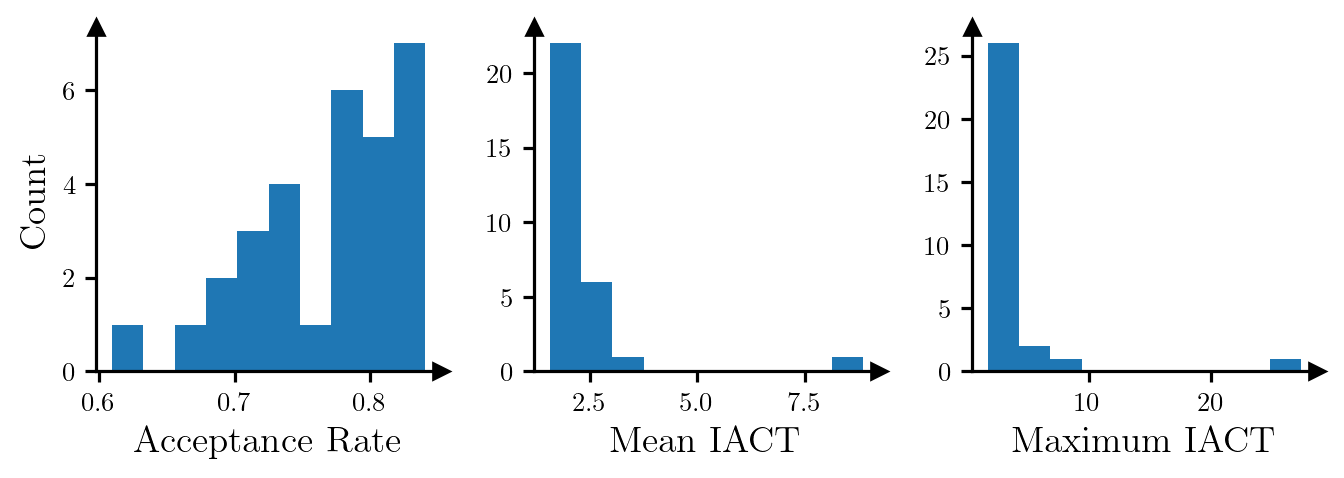

In [14]:
#| code-fold: true
#| fig-align: center
#| fig-cap: The acceptance rate, mean IACT and maximum IACT (across all parameters) for independence MCMC samplers using the conditional DIRT density as the proposal, for 30 random realisations of data.
#| label: fig-diagnostics

num_test_samples = 30

xs_test = prior.sample(num_test_samples)
logks_test = torch.vstack([prior.transform(x_i) for x_i in xs_test])
noise_test = sd_noise * torch.randn((num_test_samples, model.num_obs))
ys_test = torch.vstack([
    model.observe(model.solve(logks_test[i])) + noise_test[i]
    for i in range(num_test_samples)
])

acceptance_rates = torch.zeros((num_test_samples,))
mean_iacts = torch.zeros((num_test_samples,))
max_iacts = torch.zeros((num_test_samples,))

rs = dirt.reference.random(n=5000, d=prior.dim)

for i in range(num_test_samples):

    xs_cond, neglogfxs_cond_dirt = dirt.eval_cirt(ys_test[i], rs)
    neglogfxs_cond_true = neglogpost(xs_cond, ys_test[i])

    res = dt.run_independence_sampler(
        xs_cond, 
        neglogfxs_cond_dirt, 
        neglogfxs_cond_true
    )

    acceptance_rates[i] = res.acceptance_rate
    mean_iacts[i] = res.iacts.mean()
    max_iacts[i] = res.iacts.max()

fig, axes = plt.subplots(1, 3, figsize=(7, 2.5))

axes[0].hist(acceptance_rates)
axes[1].hist(mean_iacts)
axes[2].hist(max_iacts)

axes[0].set_xlabel("Acceptance Rate")
axes[1].set_xlabel("Mean IACT")
axes[2].set_xlabel("Maximum IACT")

axes[0].set_ylabel("Count")

for ax in axes.flat:
    ax.set_box_aspect(1)
    add_arrows(ax)